In [8]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [9]:
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors.standard_errors import pauli_error

model = NoiseModel()
error = pauli_error([("I",0.9),("X",0.1)])
model.add_all_qubit_quantum_error(error, ["id"])

print(error)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.9, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘
  P(1) = 0.1, Circuit = 
   ┌───┐
q: ┤ X ├
   └───┘


In [10]:
circuit = QuantumCircuit(5,2)

circuit.cx(0, [1,2])
circuit.barrier()



CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [11]:
circuit.id([0,1,2])
circuit.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

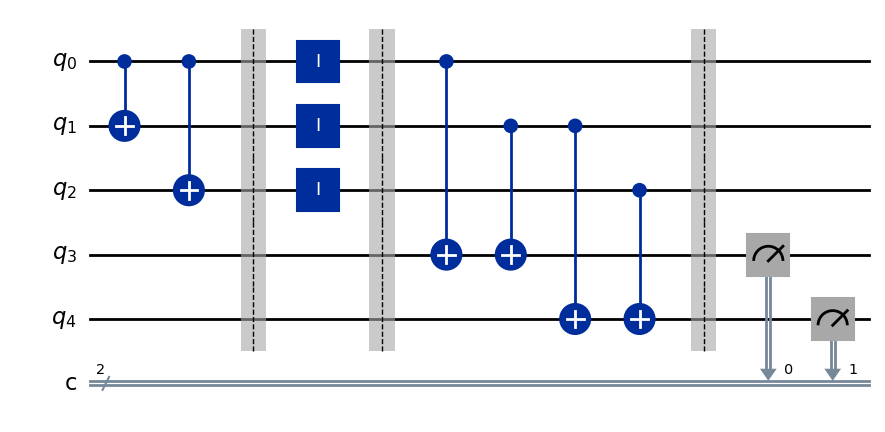

In [12]:
circuit.cx(0,3)
circuit.cx(1,3)
circuit.cx(1,4)
circuit.cx(2,4)
circuit.barrier()

circuit.measure([3,4],[0,1])
circuit.draw("mpl")

In [13]:
sim = AerSimulator()

compiled_circuit = transpile(circuit, sim, optimization_level=0)

job = sim.run(compiled_circuit, shots=1000, noise_model=model,basis_gates=model.basis_gates) 
result = job.result()

counts = result.get_counts(compiled_circuit)
print(counts)

{'01': 97, '10': 97, '00': 716, '11': 90}
